# F1 Telemetry EDA

Exploring the historical OpenF1 telemetry data to understand the structure and plot the car paths to approximate track boundaries.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

/Users/dikshamenghmalani/Github/F1_Distributed/F1-Distributed-Processing/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Fetch Session Data

We will use a recent session and a specific driver (e.g., Max Verstappen, driver_number=1) to fetch location data.

In [2]:
# Let's fetch the latest session key first
session_url = 'https://api.openf1.org/v1/sessions?year=2024'
session_resp = requests.get(session_url)
sessions = session_resp.json()

# Get the most recent session
latest_session = sessions[-1]
session_key = latest_session['session_key']
print(f"Latest Session Key: {session_key}, Location: {latest_session.get('location', 'Unknown')}")

Latest Session Key: 9662, Location: Yas Island


## Fetch Location Telemetry Data

In [3]:
driver_num = 1
# Note: This might fetch a lot of data, so we limit it or just pull the whole array and see.
location_url = f'https://api.openf1.org/v1/location?session_key={session_key}&driver_number={driver_num}'
print(f"Fetching location data from: {location_url}")

loc_resp = requests.get(location_url)
loc_data = loc_resp.json()

df = pd.DataFrame(loc_data)
df['date'] = pd.to_datetime(df['date'])
df.head()

Fetching location data from: https://api.openf1.org/v1/location?session_key=9662&driver_number=1


,date,session_key,x,y,meeting_key,driver_number,z
0,2024-12-08 12:06:49.443000+00:00,9662,0,0,1252,1,0
1,2024-12-08 12:06:49.683000+00:00,9662,0,0,1252,1,0
2,2024-12-08 12:06:49.843000+00:00,9662,0,0,1252,1,0
3,2024-12-08 12:06:50.123000+00:00,9662,0,0,1252,1,0
4,2024-12-08 12:06:50.283000+00:00,9662,0,0,1252,1,0


## Plot the Track Path

The coordinates `x` and `y` represent the 2D position on the track. Plotting them should give us a map of the track.

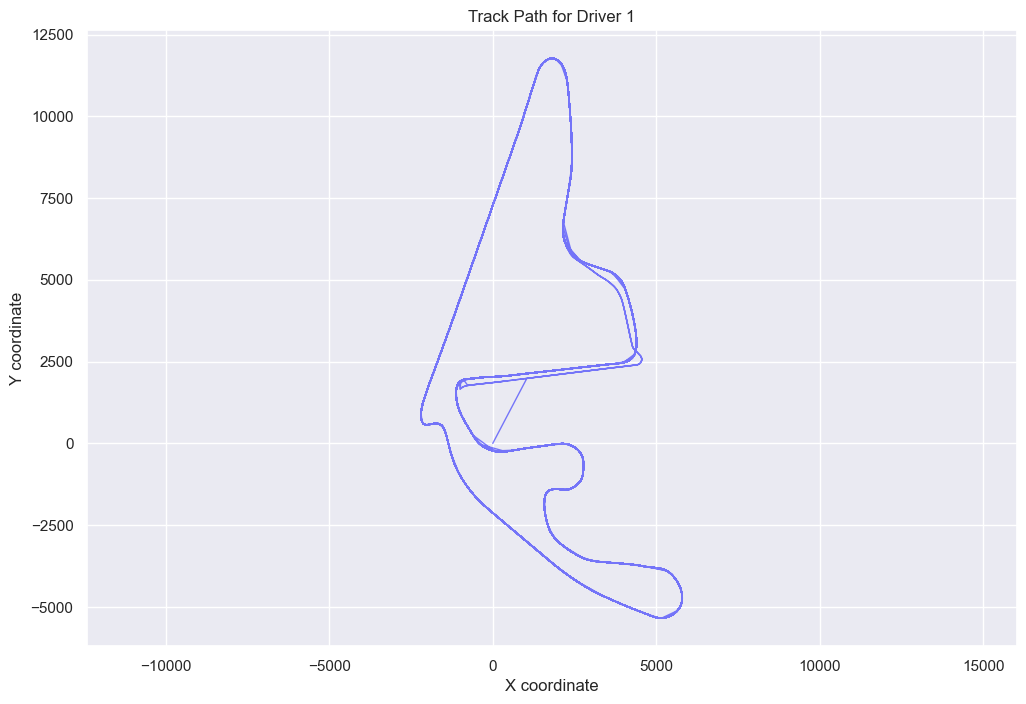

In [4]:
plt.figure(figsize=(12, 8))
plt.plot(df['x'], df['y'], color='blue', alpha=0.5, linewidth=1)
plt.title(f"Track Path for Driver {driver_num}")
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.axis('equal') # Important to keep the track shape realistic
plt.show()

## Observations
- The coordinates form the shape of the track.
- To detect anomalies, we can establish a path polygon or standard trajectory, and check if new telemetry points deviate by more than X units from this trajectory using Redis Geospatial queries.